In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random


In [ ]:
torch.manual_seed(0)
random.seed(0)

vocab_size = 3
seq_len = 3
hidden_size = 40
num_epochs = 1000

def generate_sample():
    tokens = [random.randint(0, vocab_size - 1) for _ in range(seq_len)]
    x = F.one_hot(torch.tensor(tokens), num_classes=vocab_size).float().unsqueeze(0)
    y = torch.tensor(tokens).unsqueeze(0)
    return x, y

class RNN_AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.decoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        _, h = self.encoder(x)
        dec_input = torch.zeros((1, 1, vocab_size))
        outputs = []
        for _ in range(seq_len):
            dec_out, h = self.decoder(dec_input, h)
            logits = self.out(dec_out)
            outputs.append(logits)
            dec_input = logits.detach()
        return torch.cat(outputs, dim=1)

model = RNN_AE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    x, y = generate_sample()
    logits = model(x)
    loss = sum(criterion(logits[:, t], y[:, t]) for t in range(seq_len)) / seq_len
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        pred = logits.argmax(dim=2)
        print(f"Epoch {epoch}: Loss={loss.item():.4f}, Predicted={pred.tolist()}, Target={y.tolist()}")


Epoch 0: Loss=1.0506, Predicted=[[0, 0, 0]], Target=[[1, 1, 0]]
Epoch 50: Loss=0.2875, Predicted=[[1, 0, 0]], Target=[[1, 0, 0]]
Epoch 100: Loss=0.6683, Predicted=[[2, 0, 2]], Target=[[2, 0, 1]]
Epoch 150: Loss=0.0450, Predicted=[[2, 1, 2]], Target=[[2, 1, 2]]
Epoch 200: Loss=0.1593, Predicted=[[1, 1, 1]], Target=[[1, 1, 1]]
Epoch 250: Loss=0.1784, Predicted=[[2, 0, 2]], Target=[[2, 0, 2]]
Epoch 300: Loss=0.0245, Predicted=[[0, 2, 1]], Target=[[0, 2, 1]]
Epoch 350: Loss=0.0185, Predicted=[[2, 2, 0]], Target=[[2, 2, 0]]
Epoch 400: Loss=0.0165, Predicted=[[0, 0, 1]], Target=[[0, 0, 1]]
Epoch 450: Loss=0.0179, Predicted=[[1, 1, 0]], Target=[[1, 1, 0]]
Epoch 500: Loss=0.0516, Predicted=[[1, 2, 1]], Target=[[1, 2, 1]]
Epoch 550: Loss=0.0045, Predicted=[[0, 0, 2]], Target=[[0, 0, 2]]
Epoch 600: Loss=0.0030, Predicted=[[0, 1, 0]], Target=[[0, 1, 0]]
Epoch 650: Loss=0.0011, Predicted=[[0, 2, 1]], Target=[[0, 2, 1]]
Epoch 700: Loss=0.0009, Predicted=[[0, 2, 1]], Target=[[0, 2, 1]]
Epoch 750: Lo

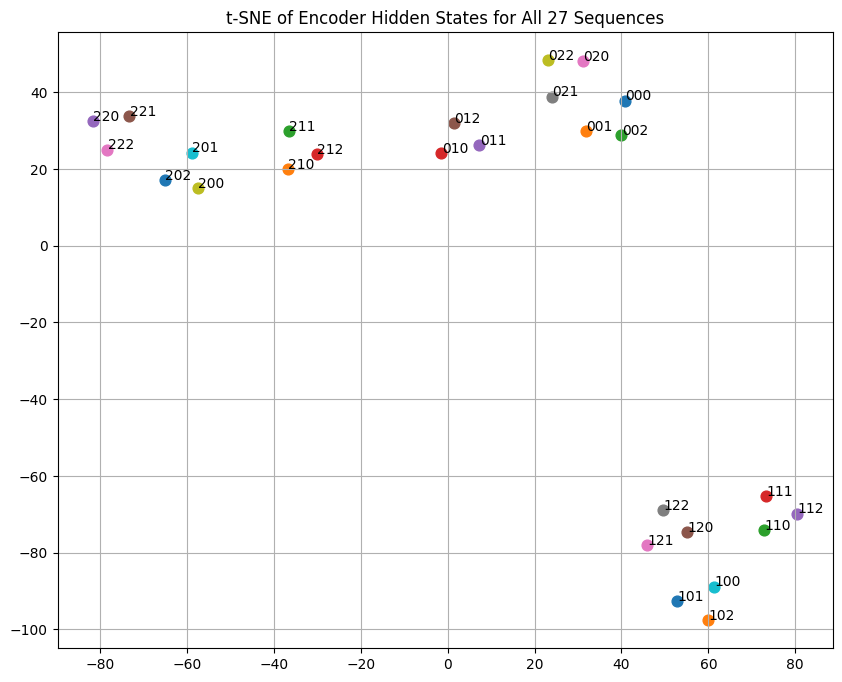

In [49]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools

# Step 1: Generate all 27 sequences
sequences = list(itertools.product(range(3), repeat=3))

# Step 2–3: Run through encoder and collect hidden states
hidden_codes = []
labels = []
model.eval()
with torch.no_grad():
    for seq in sequences:
        x = F.one_hot(torch.tensor(seq), num_classes=3).float().unsqueeze(0)  # (1, 3, 3)
        _, h = model.encoder(x)
        hidden_codes.append(h[0,0].numpy())  # extract (H,) from (1,1,H)
        labels.append("".join(map(str, seq)))

# Step 4: Reduce dimension
hidden_codes = torch.tensor(hidden_codes)
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings = tsne.fit_transform(hidden_codes)

# Step 5: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i,0], embeddings[i,1], s=60)
    plt.text(embeddings[i,0]+0.1, embeddings[i,1]+0.1, txt, fontsize=10)
plt.title("t-SNE of Encoder Hidden States for All 27 Sequences")
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Hyperparameters
vocab_size = 3          # Tokens: 0,1,2 (for 1,2,3)
embedding_dim = 8
hidden_size = 40
seq_len = 3
batch_size = 1
num_epochs = 1000

# Model
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
    
    def forward(self, x):
        embedded = self.embedding(x)
        out, h = self.rnn(embedded)
        return h  # Return final hidden state

class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h):
        embedded = self.embedding(x)
        out, _ = self.rnn(embedded, h)
        return self.fc(out)  # shape: [batch, seq_len, vocab_size]

# Full Autoencoder
class RNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, embedding_dim, hidden_size)
        self.decoder = RNNDecoder(vocab_size, embedding_dim, hidden_size)
    
    def forward(self, x, decoder_input):
        h = self.encoder(x)
        output = self.decoder(decoder_input, h)
        return output

# Instantiate model
model = RNNAutoencoder(vocab_size, embedding_dim, hidden_size)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

# Training loop
for epoch in range(num_epochs):
    batch = []
    targets = []
    for _ in range(batch_size):
        seq = [random.randint(0, vocab_size - 1) for _ in range(seq_len)]
        batch.append(seq)
        targets.append(seq)

    x = torch.tensor(batch, dtype=torch.long)
    y_true = torch.tensor(targets, dtype=torch.long)

    # Shift decoder input by one (teacher forcing with <sos>=0)
    decoder_input = torch.cat([torch.zeros((batch_size, 1), dtype=torch.long), x[:, :-1]], dim=1)

    optimizer.zero_grad()
    y_pred = model(x, decoder_input)
    loss = loss_fn(y_pred.view(-1, vocab_size), y_true.view(-1))
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 50, Loss: 0.4495
Epoch 100, Loss: 0.9207
Epoch 150, Loss: 0.4562
Epoch 200, Loss: 0.5180
Epoch 250, Loss: 1.7551
Epoch 300, Loss: 0.3702
Epoch 350, Loss: 0.4228
Epoch 400, Loss: 0.4825
Epoch 450, Loss: 0.2549
Epoch 500, Loss: 0.5995
Epoch 550, Loss: 0.5301
Epoch 600, Loss: 0.5380
Epoch 650, Loss: 0.2080
Epoch 700, Loss: 0.5829
Epoch 750, Loss: 0.0078
Epoch 800, Loss: 0.0373
Epoch 850, Loss: 0.1165
Epoch 900, Loss: 1.1797
Epoch 950, Loss: 0.0329
Epoch 1000, Loss: 0.1267


In [53]:
y_true

tensor([[0, 2, 1]])

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_hidden_states(model, vocab_size=3, seq_len=3, method='pca'):
    model.eval()
    all_seqs = []
    all_hidden_states = []

    # Generate all 27 possible sequences of length 3
    from itertools import product
    sequences = list(product(range(vocab_size), repeat=seq_len))

    for seq in sequences:
        x = torch.tensor(seq, dtype=torch.long).unsqueeze(0)  # shape [1, seq_len]
        with torch.no_grad():
            h = model.encoder(x)  # shape [1, 1, hidden_size]
        all_hidden_states.append(h.squeeze().numpy())
        all_seqs.append("".join(str(s+1) for s in seq))  # label as string e.g., '123'

    X = np.array(all_hidden_states)

    # Reduce to 2D
    if method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=5, init='random', random_state=42)
    else:
        reducer = PCA(n_components=2)
    
    X_2d = reducer.fit_transform(X)

    # Plot
    plt.figure(figsize=(8, 6))
    for i, (x, y) in enumerate(X_2d):
        plt.scatter(x, y, c='blue')
        plt.text(x + 0.1, y, all_seqs[i], fontsize=9)
    
    plt.title(f"Hidden State Representation ({method.upper()})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


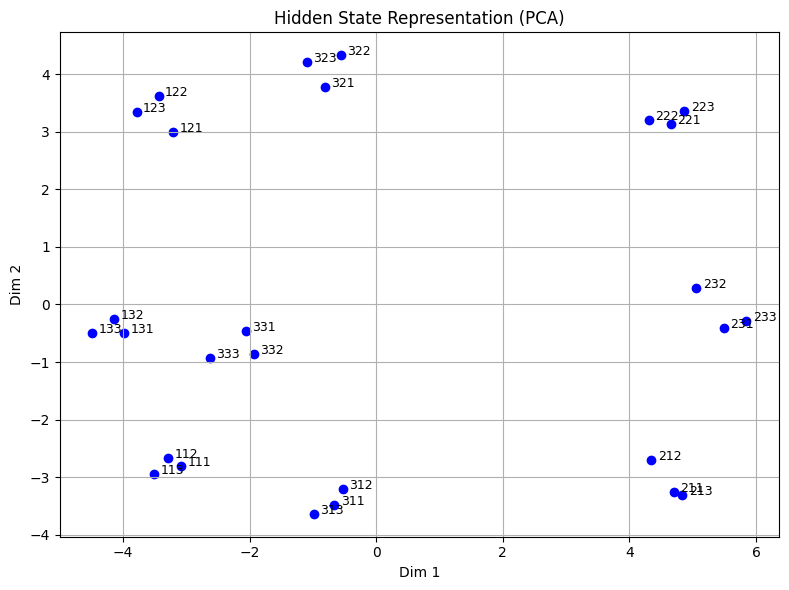

In [42]:
visualize_hidden_states(model)